Nama: Aullya Nadine Kuswandi  
NIM: 2802405125  
Kelas: LA09

Link Video Presentasi:  
https://drive.google.com/drive/folders/1cdVT8wNPluTJjM1Vew_XfcV2F56yknl8?usp=drive_link

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, KFold, GridSearchCV

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [98]:
d1 = pd.read_csv('A.csv')
d2 = pd.read_csv('A_targets.csv')

In [99]:
d1.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [100]:
d2.head()

,Student_ID,placement_status,salary_lpa
0,1,Placed,14.95
1,2,Placed,14.91
2,3,Placed,17.73
3,4,Placed,14.52
4,5,Placed,15.91


In [101]:
df = pd.merge(d1, d2, on='Student_ID')
df

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,Female,IT,10.00,90.4,98.3,0,3.7,75.3,6,...,2,7.3,2,No,Medium,Tier 3,Yes,Low,Placed,19.35
4996,4997,Male,IT,7.76,74.3,72.6,2,6.3,72.3,4,...,2,7.8,6,No,Low,Tier 1,Yes,Low,Not Placed,0.00
4997,4998,Male,IT,7.79,64.0,71.2,2,2.0,63.8,6,...,2,6.1,5,Yes,Low,Tier 2,No,Medium,Placed,19.13
4998,4999,Female,ECE,8.76,74.3,74.0,0,5.1,72.0,6,...,5,9.0,10,No,Medium,Tier 2,Yes,High,Placed,16.53


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

Dataset ini terdiri dari 5000 row dan 25 column dengan 23 fitur dan 2 target, placement status untuk target klasifikasi dan salary_lpa untuk target regresi.  

Karena Student_ID merupakan variable unique identifier yang tidak memberikan meaningful information untuk prediksi target, maka akan didrop sejak awal. Di projek ini akan saya drop sekaligus saat split dataset

In [103]:
df['placement_status'].value_counts()

placement_status
Placed        4303
Not Placed     697
Name: count, dtype: int64

Target untuk klasifikasi sangat tidak balanced (unbalanced)

# Encode Target Classification
placement_status akan diencode karena dalam mencoba berbagai algoritma atau model, saya menggunakan XGB yang mengharuskan target dalam bentuk angka

In [104]:
df['placement_status'] = df['placement_status'].replace({
    'Not Placed': 0,
    'Placed': 1
})

# Split Dataset

In [105]:
X = df.drop(columns=['Student_ID','placement_status', 'salary_lpa'])
Y_salary = df['salary_lpa']
Y_placement = df['placement_status']

X_train, X_test, Y_placement_train, Y_placement_test, Y_salary_train, Y_salary_test = train_test_split(
    X,
    Y_placement,
    Y_salary,
    test_size=0.2,
    random_state=42,
    stratify=Y_placement)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_salary_train shape:", Y_salary_train.shape)
print("Y_salary_test shape:", Y_salary_test.shape)
print("Y_placement_train shape:", Y_placement_train.shape)
print("Y_placement_test shape:", Y_placement_test.shape)

X_train shape: (4000, 22)
X_test shape: (1000, 22)
Y_salary_train shape: (4000,)
Y_salary_test shape: (1000,)
Y_placement_train shape: (4000,)
Y_placement_test shape: (1000,)


Untuk kepentingan mengecek apakah ada duplikasi pada training data, disini saya akan menggabungkan data x & y sehingga menjadi data train dan data test. 

In [106]:
train = pd.concat([X_train, Y_salary_train, Y_placement_train], axis=1)
test = pd.concat([X_test, Y_salary_test, Y_placement_test], axis=1)

Pada projek ini saya berasumsi bahwa kita diminta memprediksi apakah mahasiswa berhasil mendapatkan kerja dan berapa estimasi gaji yang didapat dari pekerjaan tersebut. Oleh karena itu, untuk regresi saya filter hanya untuk placement_status == 1, karena kembali ke asumsi saya tadi, saya ingin mengestimasi gaji dari mahasiswa yang memang mendapat pekerjaan, bukan dari keseluruhan populasi

In [107]:
train_reg = train[train['placement_status']==1]
test_reg = test[test['placement_status']==1]

In [108]:
train_reg.shape

(3442, 24)

In [109]:
test_reg.shape

(861, 24)

Pembuktian hasil splitting dataset regresi tetap kisaran 80:20

In [110]:
perc_reg_train = (3442/(861+3442))*100
perc_reg_test = (861/(861+3442))*100

print(f"Persentase data train regresi: {perc_reg_train:.2f}")
print(f"Persentase data test regresi: {perc_reg_test:.2f}")

Persentase data train regresi: 79.99
Persentase data test regresi: 20.01


# EDA

## Check Duplicate

In [111]:
sum(train.duplicated())

0

In [112]:
sum(train_reg.duplicated())

0

## Check Missing Value

### Classification Dataset

In [113]:
train.isnull().sum()

gender                           0
branch                           0
cgpa                             0
tenth_percentage                 0
twelfth_percentage               0
backlogs                         0
study_hours_per_day              0
attendance_percentage            0
projects_completed               0
internships_completed            0
coding_skill_rating              0
communication_skill_rating       0
aptitude_skill_rating            0
hackathons_participated          0
certifications_count             0
sleep_hours                      0
stress_level                     0
part_time_job                    0
family_income_level              0
city_tier                        0
internet_access                  0
extracurricular_involvement    808
salary_lpa                       0
placement_status                 0
dtype: int64

In [114]:
test.isnull().sum()

gender                           0
branch                           0
cgpa                             0
tenth_percentage                 0
twelfth_percentage               0
backlogs                         0
study_hours_per_day              0
attendance_percentage            0
projects_completed               0
internships_completed            0
coding_skill_rating              0
communication_skill_rating       0
aptitude_skill_rating            0
hackathons_participated          0
certifications_count             0
sleep_hours                      0
stress_level                     0
part_time_job                    0
family_income_level              0
city_tier                        0
internet_access                  0
extracurricular_involvement    198
salary_lpa                       0
placement_status                 0
dtype: int64

Terdapat missing value pada variable extracurricular_involvement baik pada dataset training maupun testing klasifikasi.

### Regression Dataset

In [115]:
train_reg.isnull().sum()

gender                           0
branch                           0
cgpa                             0
tenth_percentage                 0
twelfth_percentage               0
backlogs                         0
study_hours_per_day              0
attendance_percentage            0
projects_completed               0
internships_completed            0
coding_skill_rating              0
communication_skill_rating       0
aptitude_skill_rating            0
hackathons_participated          0
certifications_count             0
sleep_hours                      0
stress_level                     0
part_time_job                    0
family_income_level              0
city_tier                        0
internet_access                  0
extracurricular_involvement    709
salary_lpa                       0
placement_status                 0
dtype: int64

In [116]:
test_reg.isnull().sum()

gender                           0
branch                           0
cgpa                             0
tenth_percentage                 0
twelfth_percentage               0
backlogs                         0
study_hours_per_day              0
attendance_percentage            0
projects_completed               0
internships_completed            0
coding_skill_rating              0
communication_skill_rating       0
aptitude_skill_rating            0
hackathons_participated          0
certifications_count             0
sleep_hours                      0
stress_level                     0
part_time_job                    0
family_income_level              0
city_tier                        0
internet_access                  0
extracurricular_involvement    172
salary_lpa                       0
placement_status                 0
dtype: int64

Pada dataset training dan testing untuk regresi juga terdapat missing value di kolom yang sama, yaitu extracurricular_involvement

## Inconsistent Value

### Classification Dataset

In [117]:
num_col = [c for c in train.columns if train[c].dtype != 'object']
cat_col = [c for c in train.columns if train[c].dtype == 'object']

In [118]:
for c in cat_col:
    print(f"Total unique values in {c}: {train[c].nunique()}")
    print(train[c].value_counts(), "\n")

Total unique values in gender: 2
gender
Male      2384
Female    1616
Name: count, dtype: int64 

Total unique values in branch: 5
branch
CSE    1217
ECE    1065
IT      781
ME      576
CE      361
Name: count, dtype: int64 

Total unique values in part_time_job: 2
part_time_job
No     3211
Yes     789
Name: count, dtype: int64 

Total unique values in family_income_level: 3
family_income_level
Medium    1965
Low       1207
High       828
Name: count, dtype: int64 

Total unique values in city_tier: 3
city_tier
Tier 2    1633
Tier 3    1240
Tier 1    1127
Name: count, dtype: int64 

Total unique values in internet_access: 2
internet_access
Yes    3568
No      432
Name: count, dtype: int64 

Total unique values in extracurricular_involvement: 3
extracurricular_involvement
Medium    1227
Low       1159
High       806
Name: count, dtype: int64 



Tidak ada inkonsisten data pada dataset klasifikasi ini

#### Regression Dataset

In [119]:
num_col_reg = [c for c in train_reg.columns if train_reg[c].dtype != 'object']
cat_col_reg = [c for c in train_reg.columns if train_reg[c].dtype == 'object']

In [120]:
for c in cat_col_reg:
    print(f"Total unique values in {c}: {train_reg[c].nunique()}")
    print(train[c].value_counts(), "\n")

Total unique values in gender: 2
gender
Male      2384
Female    1616
Name: count, dtype: int64 

Total unique values in branch: 5
branch
CSE    1217
ECE    1065
IT      781
ME      576
CE      361
Name: count, dtype: int64 

Total unique values in part_time_job: 2
part_time_job
No     3211
Yes     789
Name: count, dtype: int64 

Total unique values in family_income_level: 3
family_income_level
Medium    1965
Low       1207
High       828
Name: count, dtype: int64 

Total unique values in city_tier: 3
city_tier
Tier 2    1633
Tier 3    1240
Tier 1    1127
Name: count, dtype: int64 

Total unique values in internet_access: 2
internet_access
Yes    3568
No      432
Name: count, dtype: int64 

Total unique values in extracurricular_involvement: 3
extracurricular_involvement
Medium    1227
Low       1159
High       806
Name: count, dtype: int64 



Tidak ada inkonsisten data pada dataset regresi ini

# Check Numeric Variables

### Classification Dataset

In [121]:
train.describe()

,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa,placement_status
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,8.283140,74.552525,74.542750,0.343000,4.020375,71.938675,5.544750,2.137000,3.735250,3.026250,4.118000,3.698500,2.841750,6.943975,6.046250,13.901248,0.860500
std,0.999398,10.216466,10.180319,0.610282,1.961447,7.733589,2.064355,1.143266,1.276348,1.410694,0.713935,1.605846,1.785078,1.149817,2.831981,6.253890,0.346511
min,5.050000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,7.600000,67.500000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,12.487500,1.000000
50%,8.310000,74.800000,74.700000,0.000000,4.000000,71.950000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,15.740000,1.000000
75%,9.010000,81.900000,81.700000,1.000000,5.300000,77.100000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,18.350000,1.000000
max,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000,1.000000


Dari describe() kita bisa melihat apakah ada anomali pada data kita, yaitu melalui nilai min dan max. Dari sini kita bisa melihat apakah data kita masih pada range yang masuk akal sesuai konteks variable tersebut. Untuk di dataset ini, range dari semua variable numerik sudah masuk akal dan sesuai dengan konteks variable tersebut

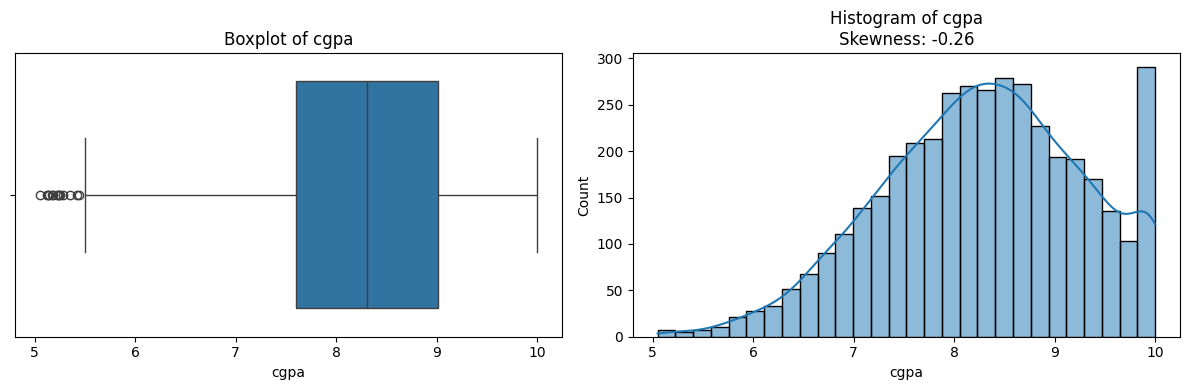

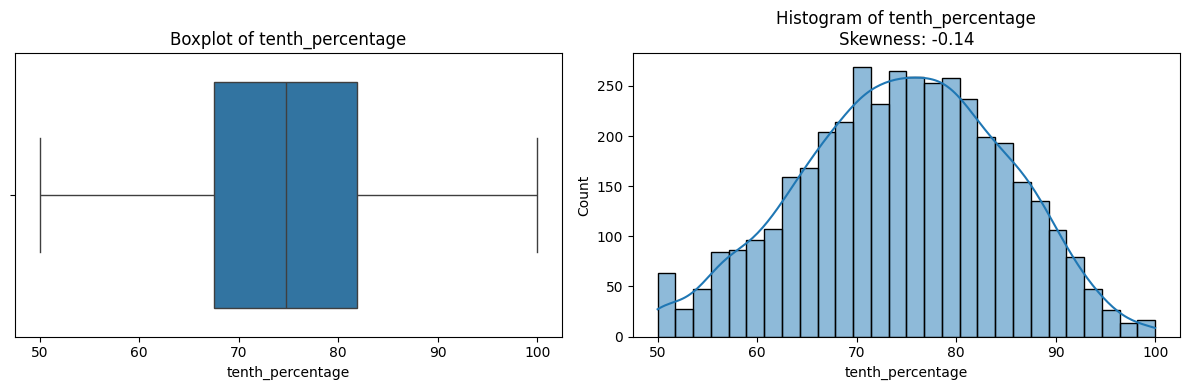

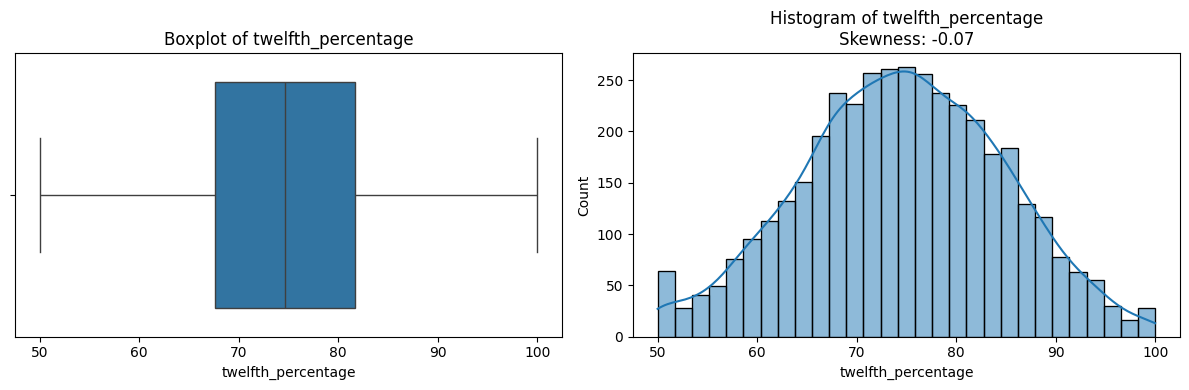

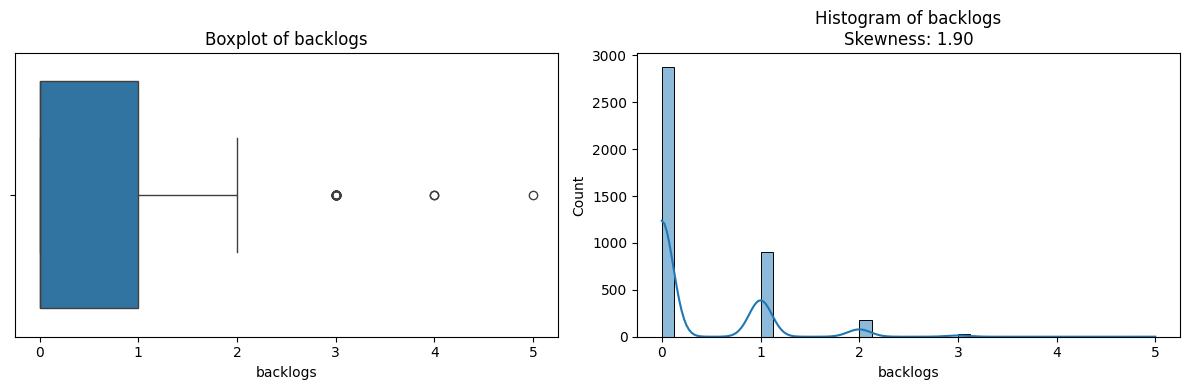

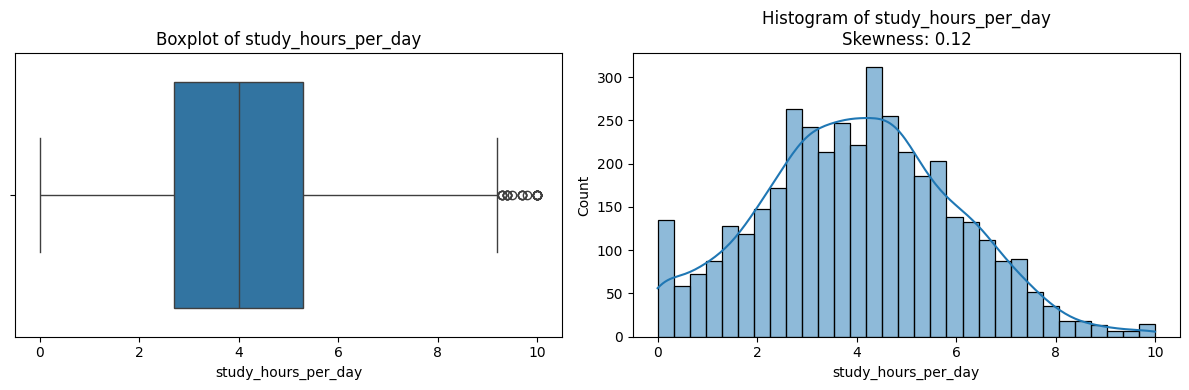

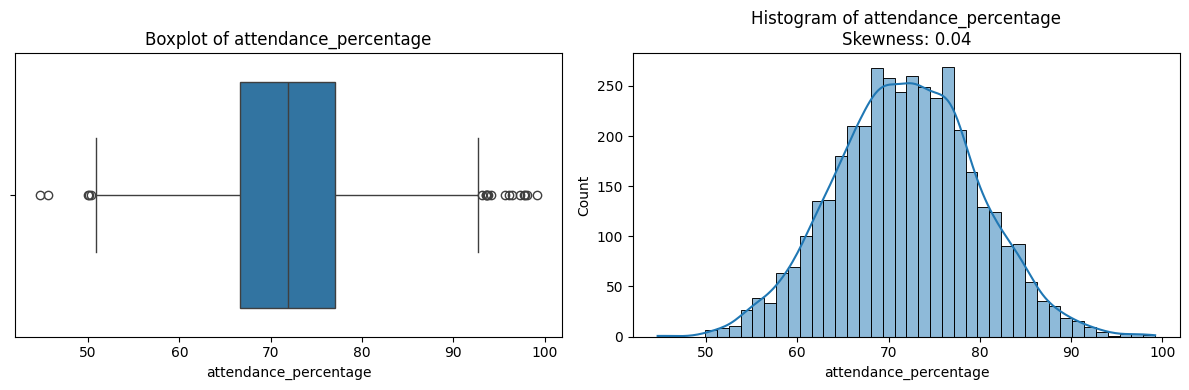

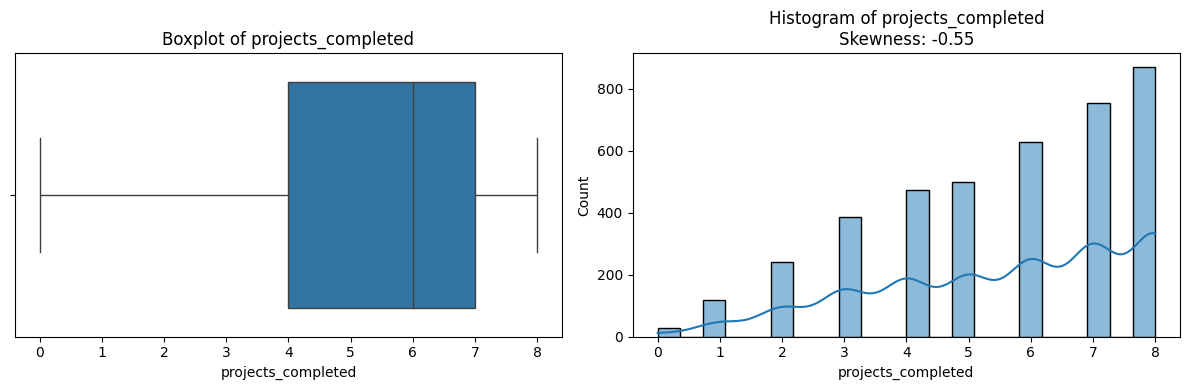

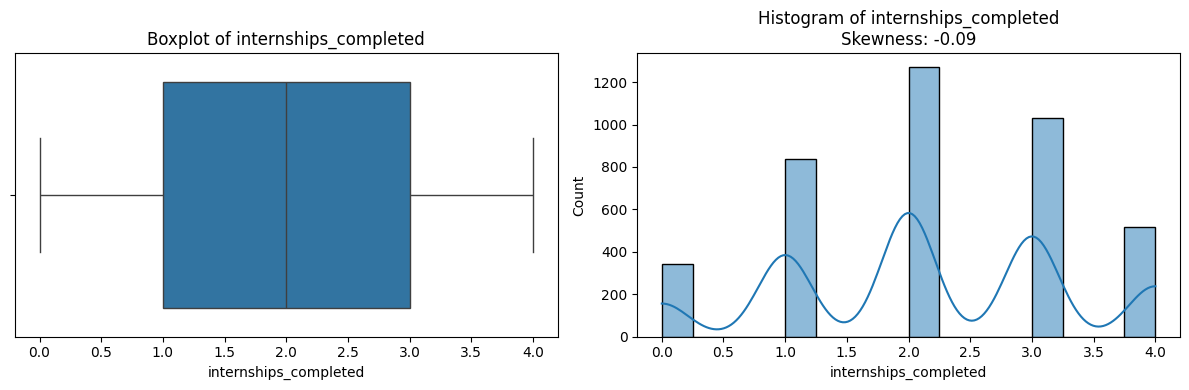

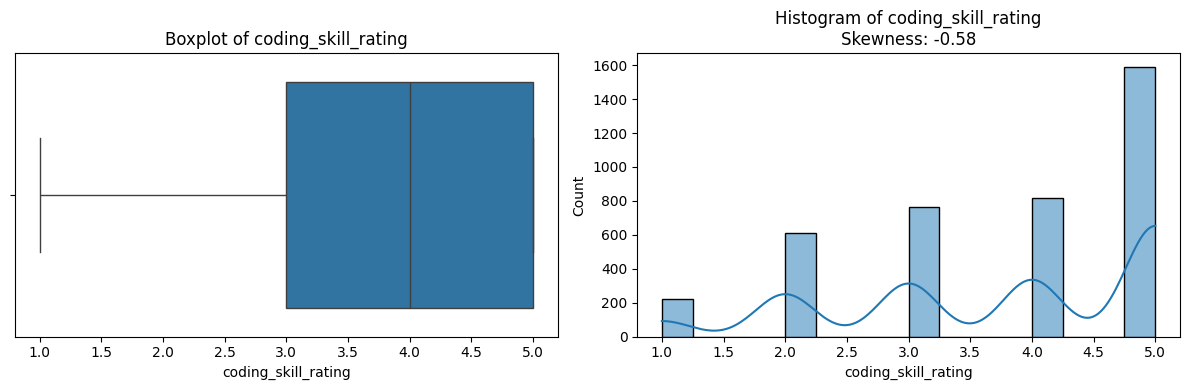

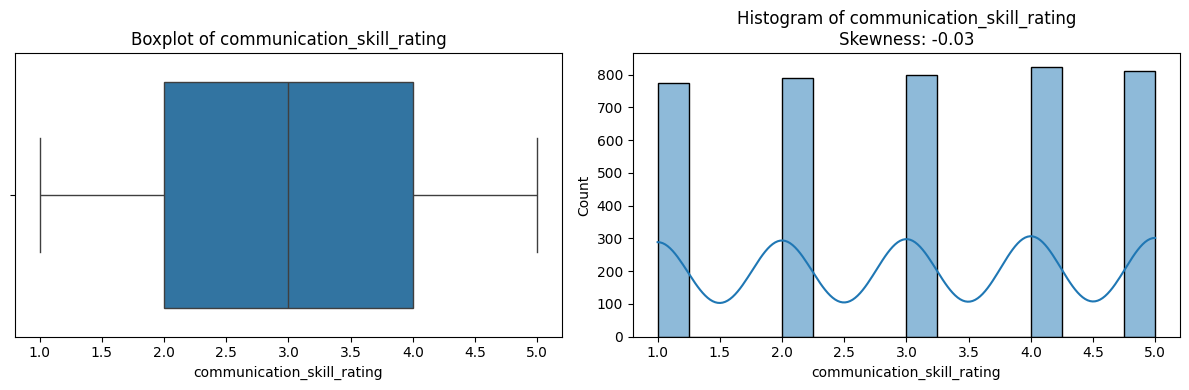

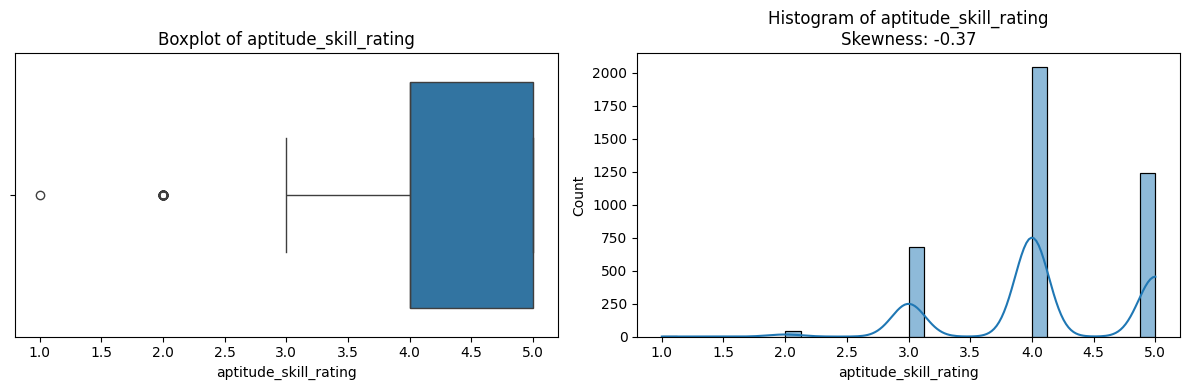

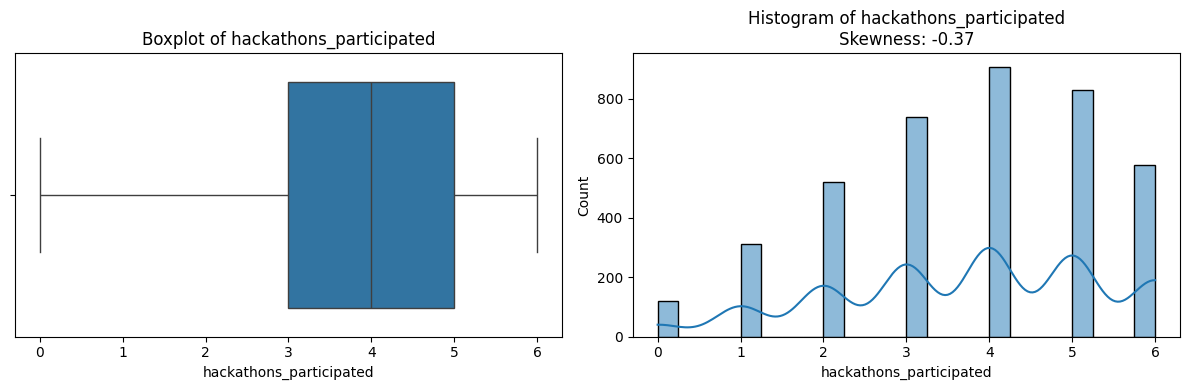

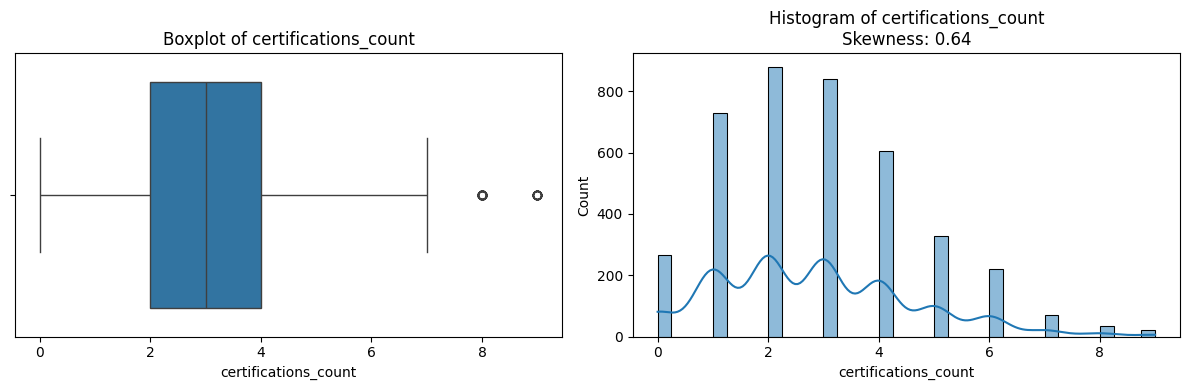

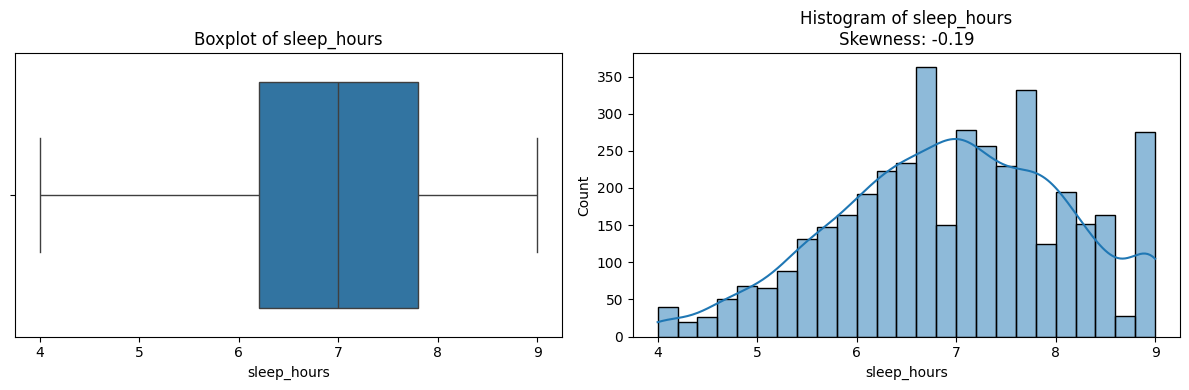

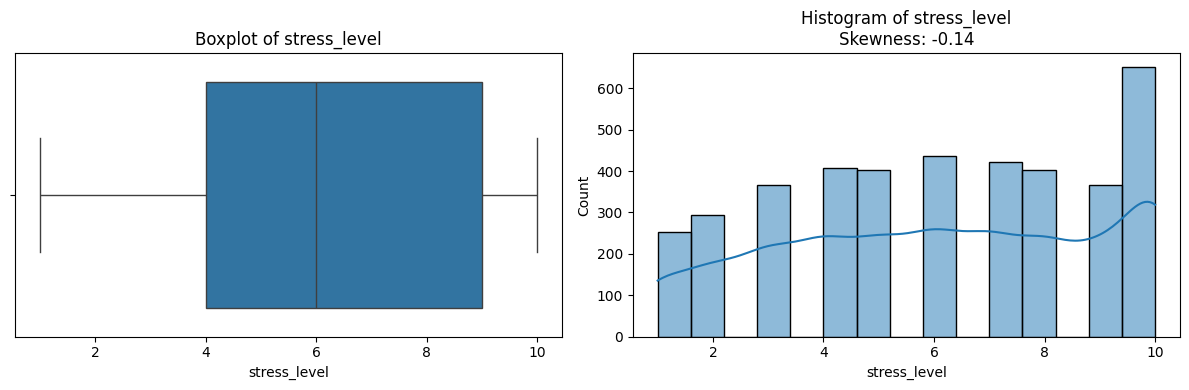

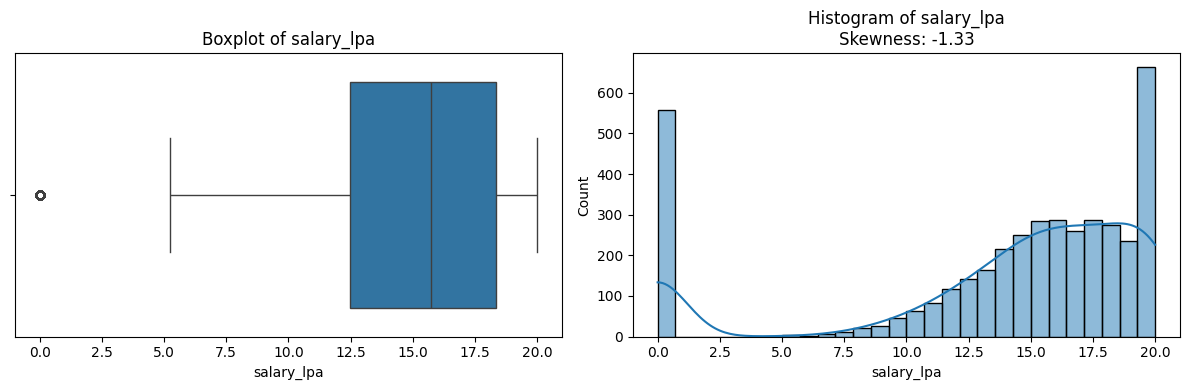

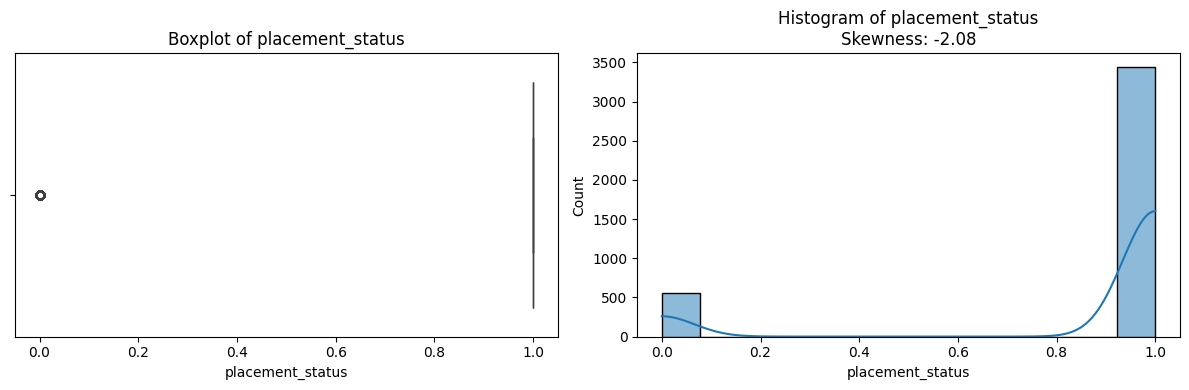

In [122]:
for col in num_col:
    skew_val = train[col].skew()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.boxplot(x=train[col], ax=axes[0])
    axes[0].set_title(f'Boxplot of {col}')
    sns.histplot(train[col].dropna(), kde=True, ax=axes[1])
    axes[1].set_title(f'Histogram of {col}\nSkewness: {skew_val:.2f}')
    
    plt.tight_layout()
    plt.show()

Terdapat outlier pada beberapa fitur, yaitu cgpa, backlogs, study_hours_per_day, attendance_percentage, aptitude_skill_rating, dan certifications_count. Namun karena outlier masih masuk akal dan bisa saja menggambarkan variasi data di dunia nyata, makanya outlier ini tidak akan saya tangani.

Untuk kolom target regresi, yaitu salary_lpa juga terdapat outlier, yaitu salary 0 dimana hal ini mungkin saja karena bisa saja mahasiswa tersebut belum memiliki pekerjaan.

Untuk distribusi numeric variable ada yang terdistribusi normal dan skewed. Namun untuk imputasi saya akan menggunakan median untuk seluruhnya. Hal ini karena pada data yang terdistribusi normal, nilai mean sama dengan median, sehingga saya akan langsung menggunakan median pada imputer di pipeline nantinya.

### Regression Dataset

In [123]:
train_reg.describe()

,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa,placement_status
count,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.0
mean,8.408640,75.641371,75.630912,0.237943,4.074782,72.082626,5.800407,2.254794,3.906740,3.075537,4.176060,3.867228,2.923591,6.946949,5.994189,16.154849,1.0
std,0.960559,9.999990,9.930857,0.484015,1.963615,7.742422,1.941597,1.119371,1.183666,1.410547,0.690641,1.544866,1.791103,1.146382,2.833656,3.006045,0.0
min,5.130000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,4.000000,1.000000,5.220000,1.0
25%,7.760000,68.800000,68.700000,0.000000,2.700000,66.800000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,14.160000,1.0
50%,8.450000,76.200000,75.700000,0.000000,4.100000,72.100000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,16.420000,1.0
75%,9.130000,83.000000,82.600000,0.000000,5.400000,77.300000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,8.000000,18.690000,1.0
max,10.000000,100.000000,100.000000,4.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000,1.0


Tidak ada anomali di numeric variabel data regresi ini

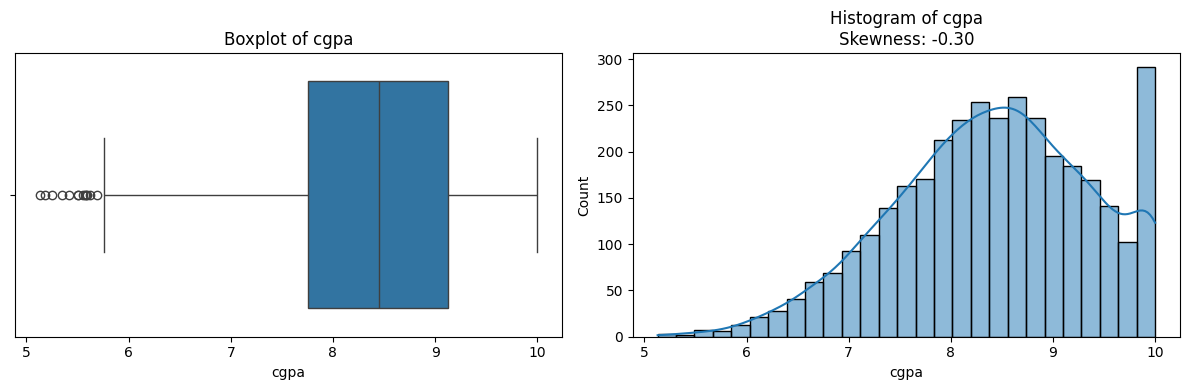

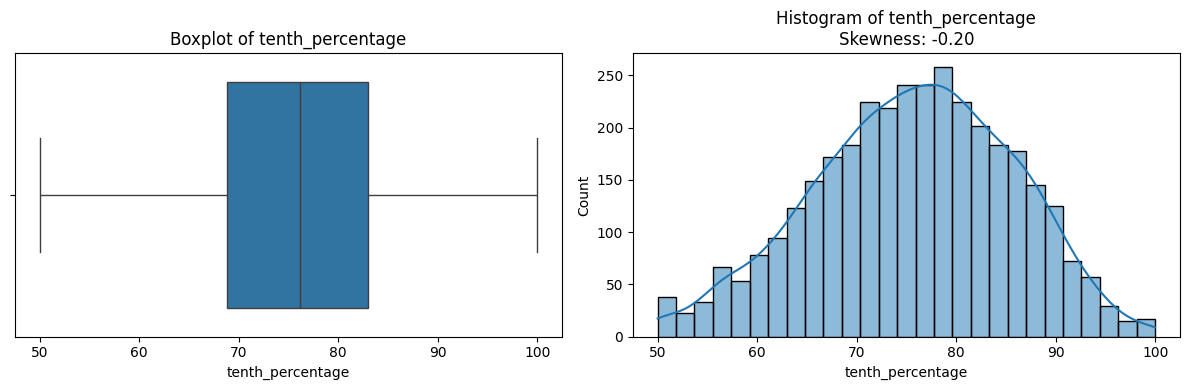

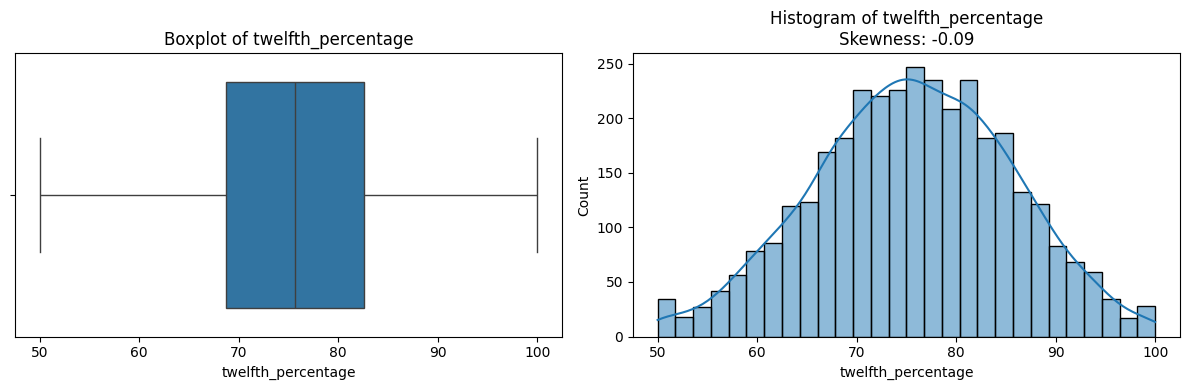

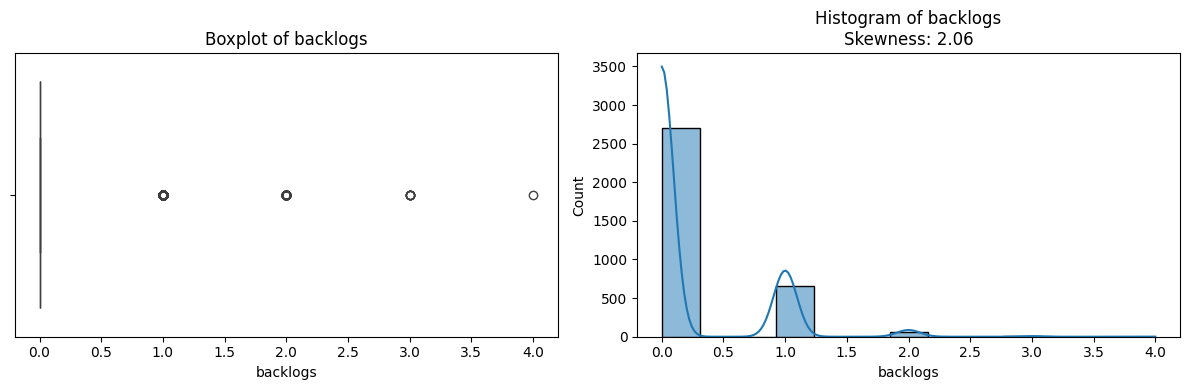

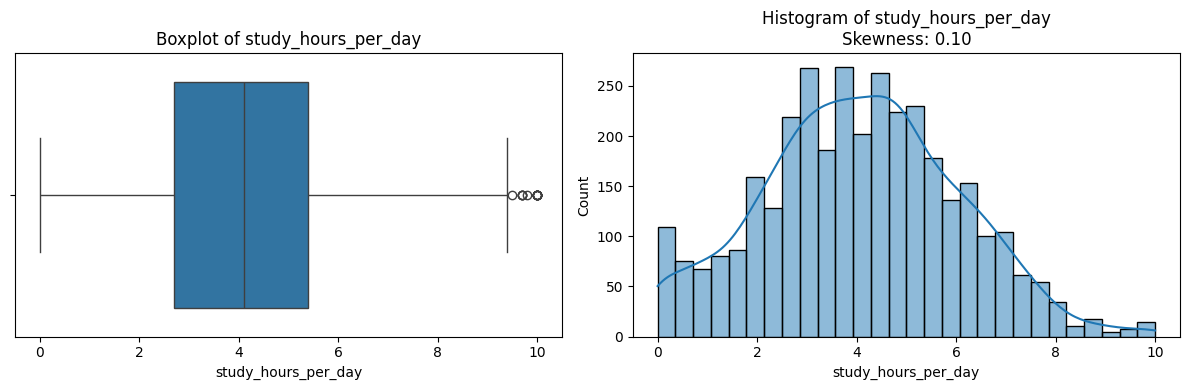

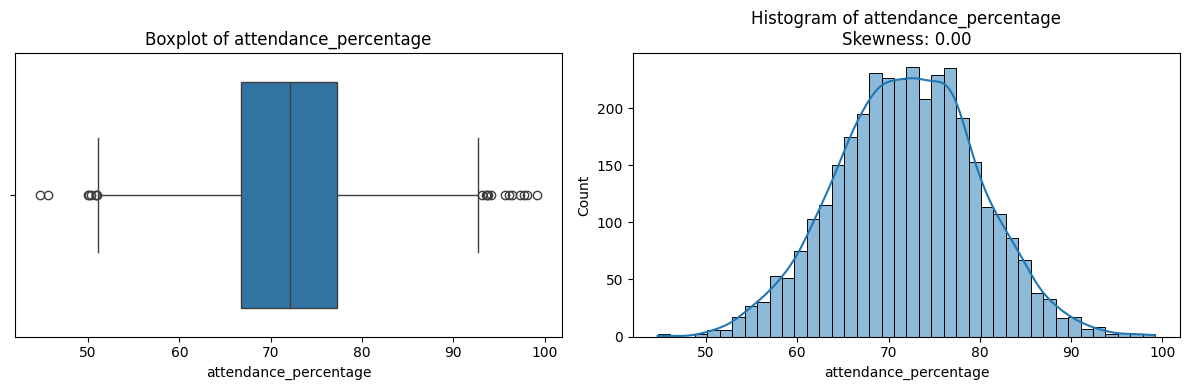

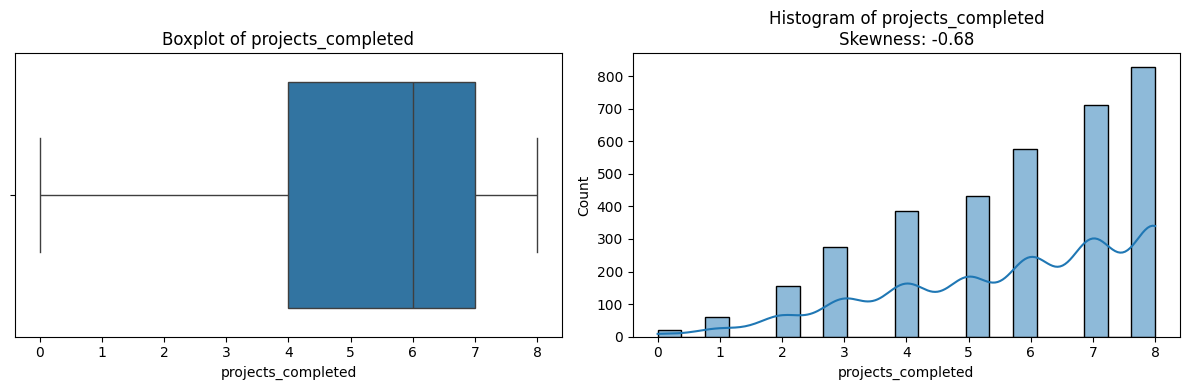

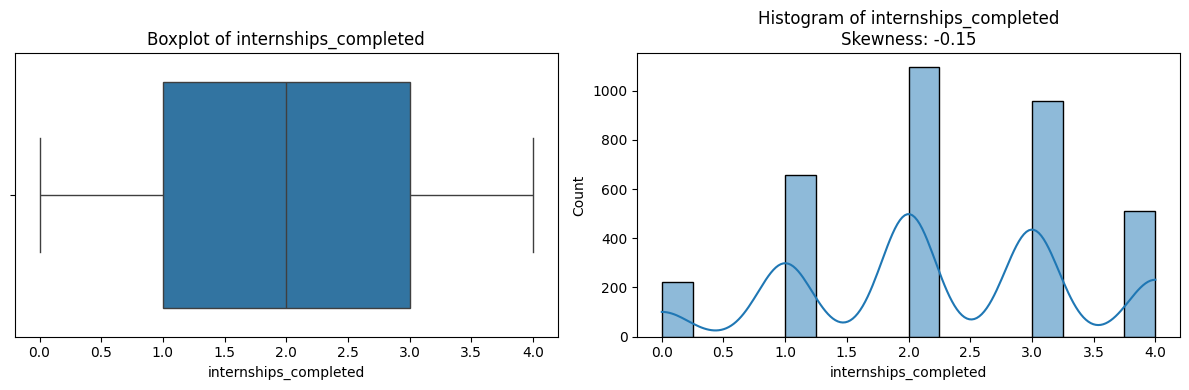

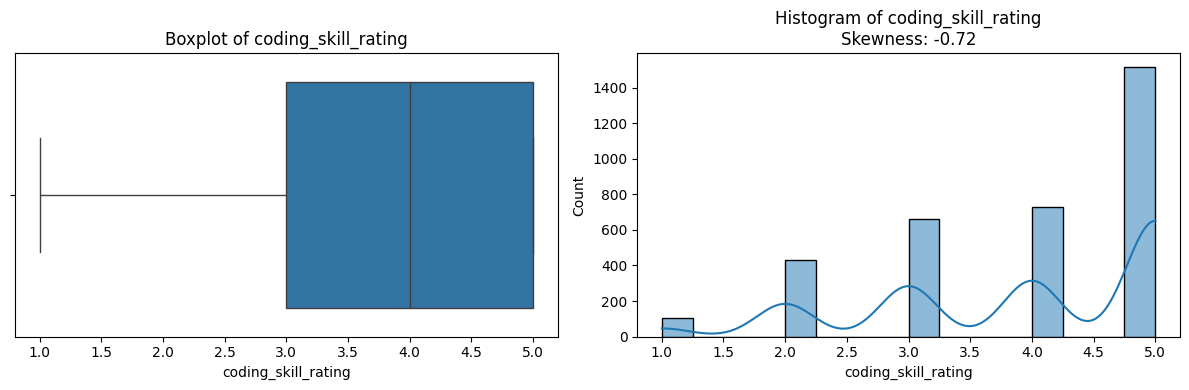

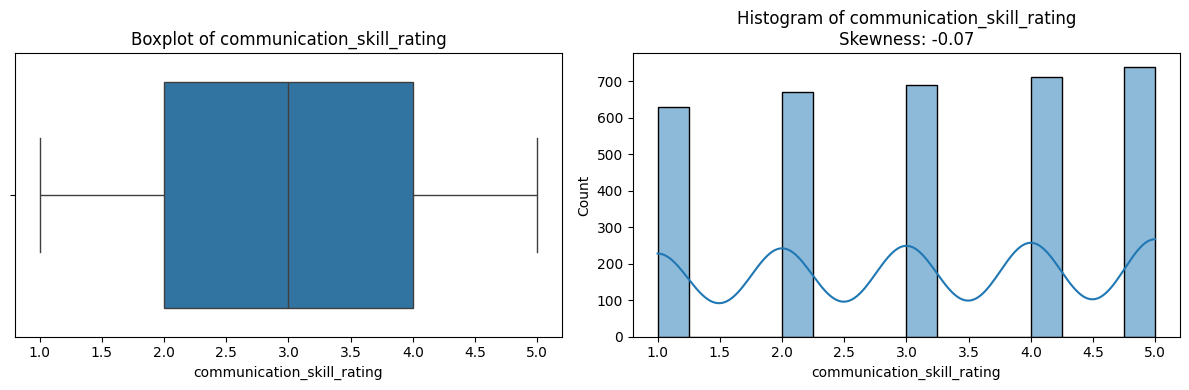

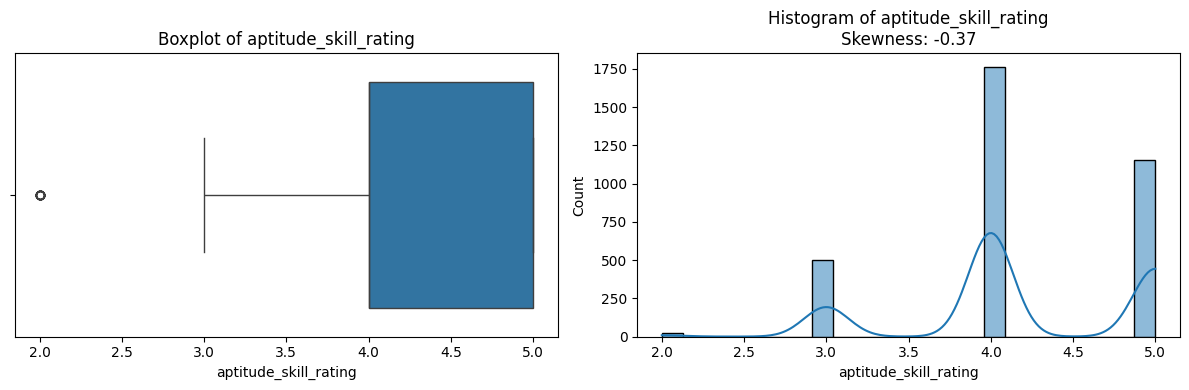

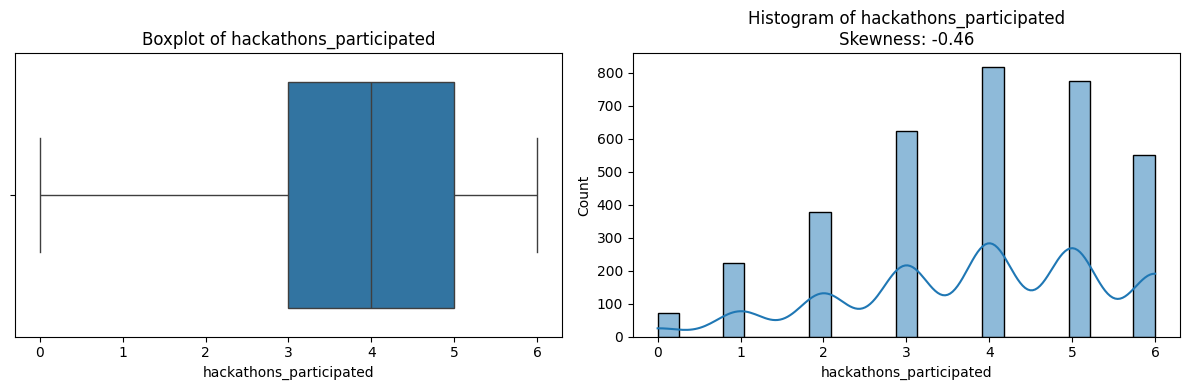

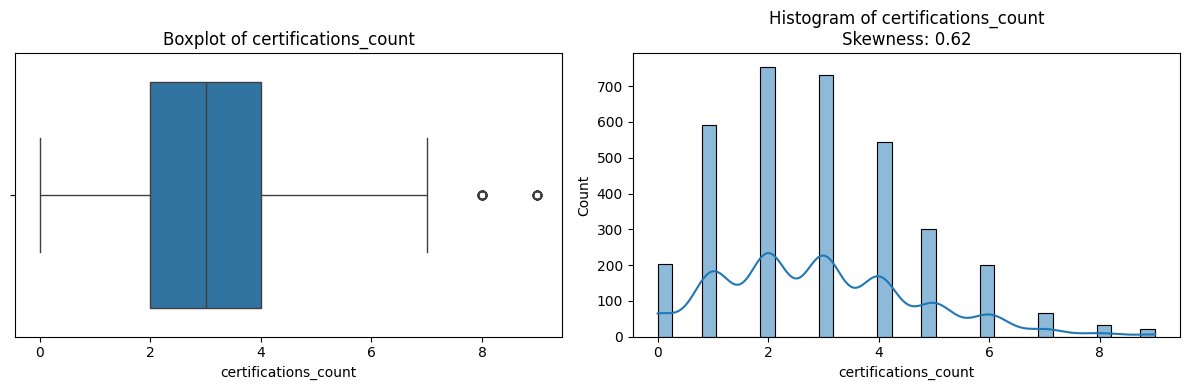

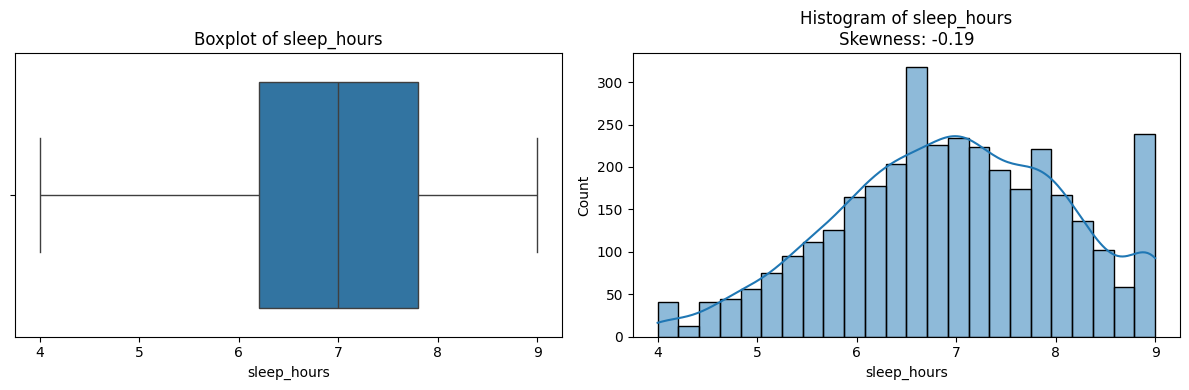

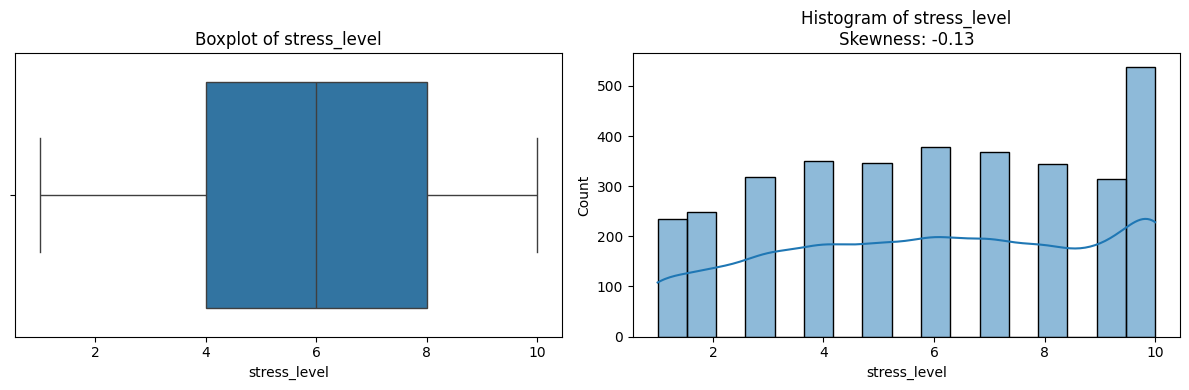

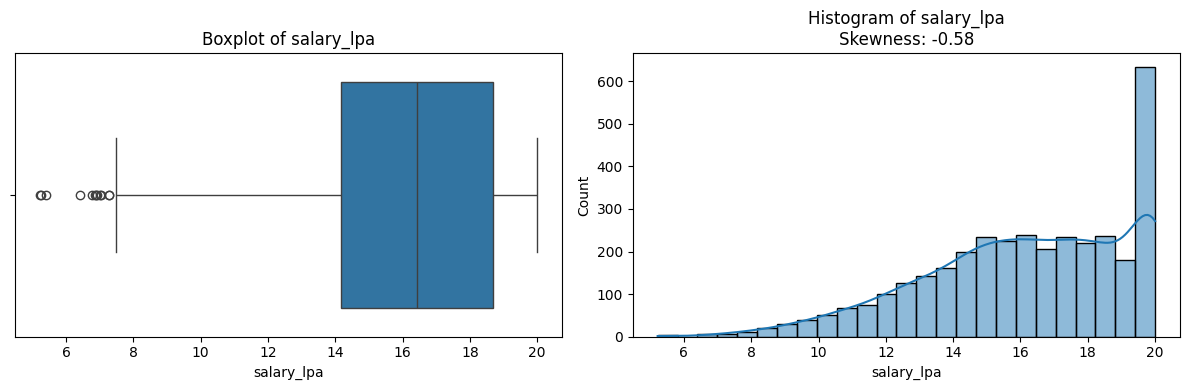

In [124]:
nume_col = [c for c in train_reg.columns if train_reg[c].dtype != 'object' and c != 'placement_status']

for col in nume_col:
    skew_val = train_reg[col].skew()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.boxplot(x=train_reg[col], ax=axes[0])
    axes[0].set_title(f'Boxplot of {col}')
    sns.histplot(train_reg[col].dropna(), kde=True, ax=axes[1])
    axes[1].set_title(f'Histogram of {col}\nSkewness: {skew_val:.2f}')
    
    plt.tight_layout()
    plt.show()

Distribusi dan karakteristik dataset antara klasifikasi dan regresi cukup mirip, sehingga pada tahap preprocessing, saya bisa menggunakan statistik dan asumsi yang sama dengan data klasifikasi

## Correlation

### Classification Dataset

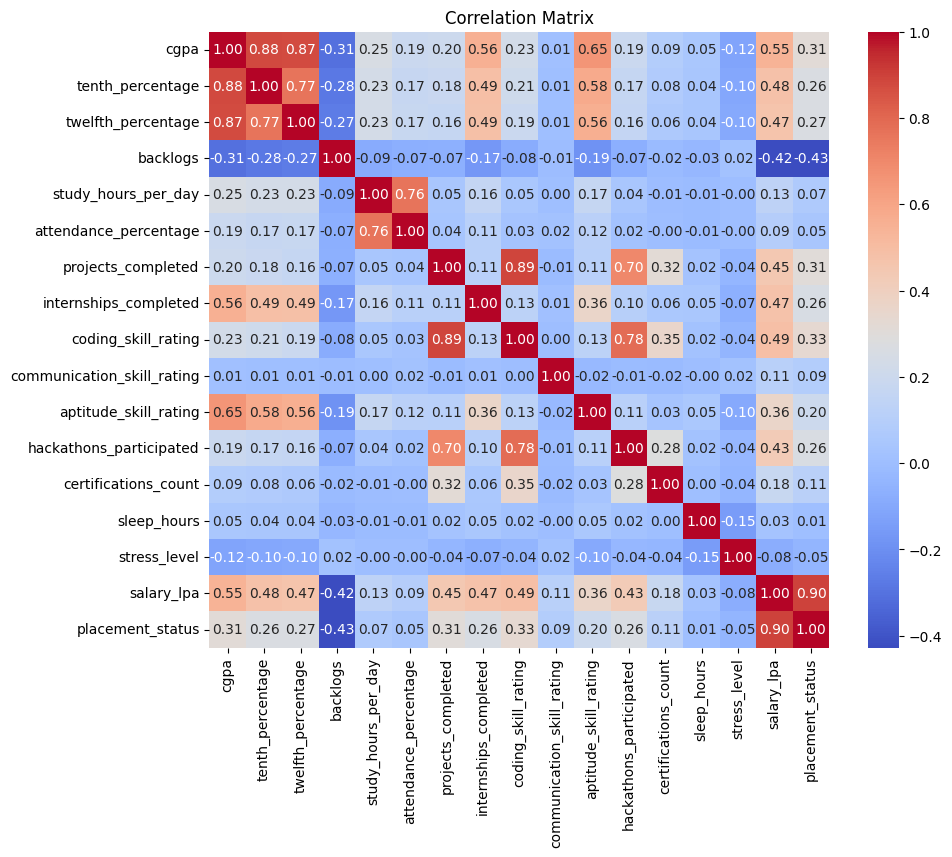

In [125]:
corr_matrix = train.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Terdapat beberapa variabel yang saling berkolerasi satu sama lain, yaitu:
- cgpa dengan tenth_percentage berkolerasi kuat positif sebesar 0.88
- cgpa dengan twelfth_percentage berkolerasi kuat positif dengan coefficient sebesar 0.87
- coding_skill_rating berkolerasi positif kuat dengan hackathons_participated sebesar 0.78
- tenth_percentage dan twelfth_percentage juga saling berkolerasi tinggi secara positif sebesar 0.77
- study_hours_per_day dan attendance_percentage juga berkolerasi positif dengan koefisien 0.76

Hal ini dapat menyebabkan multikolinearitas, namun untuk training awal, tidak akan saya tangani terlebih dahulu. Alasannya karena bisa saja meski berkolerasi tinggi, tetapi terdapat informasi tersembunyi di dalamnya. Misalnya CGPA mencerminkan performa kuliah saat ini, sementara tenth/twelfth percentage mencerminkan konsistensi prestasi di SMA.

Terkait hal ini, saya akan melakukan testing juga untuk melihat apakah ada perbedaan besar dari segi performance metric antara drop kolom berkolerasi tinggi atau tidak.

### Regression Dataset

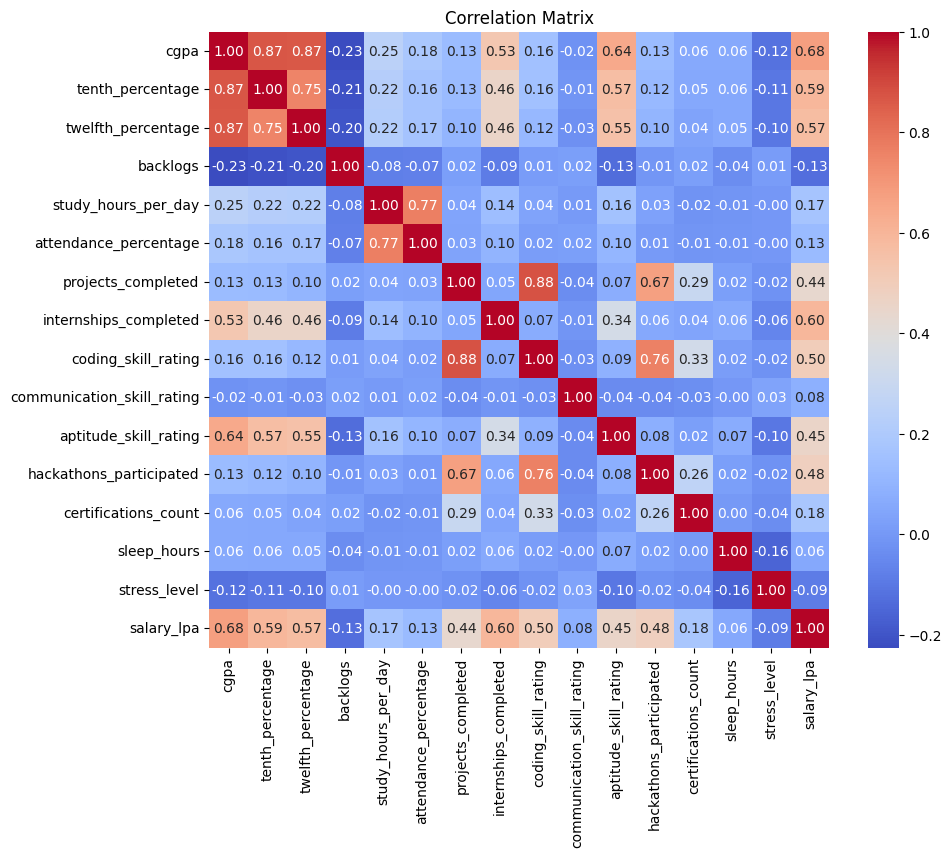

In [126]:
corr_matrix_reg = train_reg[nume_col].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_reg, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Dari correlation matrix di atas terlihat bahwa cgpa memiliki korelasi yang cukup kuat dengan salary_lpa, diikuti oleh internship_completed, tenth_percentage, dan twelfth_percentage. Keempat variable ini berkolerasi positif dengan salary_lpa yang berarti ketika value dari variable tersebut naik, salary_lpa juga ikut meningkat.

Untuk fitur lain juga banyak yang berkolerasi tinggi sama seperti pada dataset klasifikasi

# Split Feature and Target

In [127]:
x_train_cls = train.drop(columns=['placement_status', 'salary_lpa'])
y_placement_train = train['placement_status']

x_test_cls = test.drop(columns=['placement_status', 'salary_lpa'])
y_placement_test = test['placement_status']

In [128]:
x_train_reg = train_reg.drop(columns=['placement_status', 'salary_lpa'])
y_salary_train = train_reg['salary_lpa']

x_test_reg = test_reg.drop(columns=['placement_status', 'salary_lpa'])
y_salary_test = test_reg['salary_lpa']

# Pipeline (Handling Missing + Feature Engineering + Modeling)

Missing value akan ditangani dengan median sesuai penjelasan sebelumnya dan variable kategorikal akan diimpute menggunakan modus

Akan dilakukan scaling menggunakan Robust Scaler karena data yang ada terdapat outlier dan beberapa skewed. Robust Scaler menggunakan median dan IQR sehingga lebih tahan terhadap outlier

Untuk variable family_income_level, city_tier, dan extracurricular_involvement merupakan ordinal variable yang memiliki urutan/ranking. Contohnya variable family_income_level yang memiliki urutan Low, Medium, lalu High (urutan dari terendah ke tertinggi). Oleh karena itu, encoding dilakukan menggunakan Ordinal Encoder.

Kategori pada city_tier terbagi menjadi Tier 1, Tier 2, Tier 3. Dalam konteks tingkatan kota, biasa Tier 1 adalah yang paling maju, diikuti Tier 2, dan terakhir Tier 3. Sehingga urutan ordinal dari terkecil 0-2, yaitu Tier 3 (hasil encode 0), Tier 2 (hasil encode 1), Tier 1 (hasil encode 2)

Untuk branch merupakan nominal variable sehingga bisa diencode dengan OneHotEncoder

Untuk binary variable seperti gender, part_time_job, dan internet_access bisa menggunakan Label Encoder. Namun karena hasil angka encode tidak berpengaruh besar untuk binary variable (selama konsisten), pada projek ini bisa sekaligus saya masukkan ke Ordinal variable. Hal ini agar sesuai dengan encode standard seperti yes 1, no 0. Untuk gender sendiri sebenarnya tidak masalah, namun saya akan encode male 0 dan female 1

## Handling Missing Value & Feature Engineering
Dikarenakan dataset klasifikasi dan regresi memiliki karakteristik yang mirip, maka preprocessing pipelinenya bisa disamakan, hanya saja parameter x_train y_train yang dipreprocess tentu berbeda

In [129]:
exc = ['salary_lpa', 'placement_status']
num_cols = [c for c in train.columns if train[c].dtype != 'object' and c not in exc]

# Scaling & Imputasi
numeric_preprocess = Pipeline([
    ('num_imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Encoding & Imputasi
ohe_col = ['branch']
ordinal_col = ['gender', 'part_time_job', 'family_income_level', 'city_tier', 'internet_access', 'extracurricular_involvement']
ordinal_categories = [
    ['Male', 'Female'],
    ['No', 'Yes'],
    ['Low', 'Medium', 'High'],
    ['Tier 3', 'Tier 2', 'Tier 1'],
    ['No', 'Yes'],
    ['Low', 'Medium', 'High']
] 

ohe_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('cat_onehot_encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('cat_ordinal_encoder', OrdinalEncoder(categories=ordinal_categories))
])

preprocess = ColumnTransformer([
    ('num', numeric_preprocess, num_cols),
    ('ohe', ohe_preprocess, ohe_col),
    ('ordinal', ordinal_preprocess, ordinal_col)
], remainder='drop')

## Modeling

### Classification

#### a) Logistic Regression

In [130]:
lr_pred_cls = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])

lr_pred_cls_smote = ImbPipeline([
    ('preprocessing', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])

#### b) Random Forest

In [131]:
rf_pred_cls = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_pred_cls_smote = ImbPipeline([
    ('preprocessing', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

#### c) XGBoost

In [132]:
xgb_pred_cls = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', XGBClassifier(random_state=42, class_weight='balanced'))
])

xgb_pred_cls_smote = ImbPipeline([
    ('preprocessing', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42))
])

#### d) LightGBM

In [133]:
lgb_pred_cls = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', LGBMClassifier(
        random_state=42, class_weight='balanced'))
])

lgb_pred_cls_smote = ImbPipeline([
    ('preprocessing', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(random_state=42))
])

#### e) CatBoost

In [134]:
cat_pred_cls = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', CatBoostClassifier(
        random_state=42, auto_class_weights='Balanced'))
])

cat_pred_cls_smote = ImbPipeline([
    ('preprocessing', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('classifier', CatBoostClassifier(random_state=42))
])

Saya menggunakan teknik cross-validation pada proses pelatihan model untuk memastikan bahwa performa model yang diperoleh tidak hanya kebetulan baik pada satu pembagian data tertentu, melainkan konsisten dan dapat digeneralisasi dengan baik ke data lain.

### Using Class Weight Balanced

In [135]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_0': make_scorer(precision_score, pos_label=0),
    'recall_0': make_scorer(recall_score, pos_label=0),
    'f1_0': make_scorer(f1_score, pos_label=0),
    'precision_1': make_scorer(precision_score, pos_label=1),
    'recall_1': make_scorer(recall_score, pos_label=1),
    'f1_1': make_scorer(f1_score, pos_label=1),
    'f1_macro': 'f1_macro'
}

models_balanced = {
    'Logistic Regression': lr_pred_cls,
    'Random Forest': rf_pred_cls,
    'XGBoost': xgb_pred_cls,
    'LightGBM': lgb_pred_cls,
    'CatBoost': cat_pred_cls
}

cv_results_balanced = {}
for name, model in models_balanced.items():
    cv_results_balanced[name] = cross_validate(
        model, x_train_cls, y_placement_train,
        cv=skf, scoring=scoring, n_jobs=-1
    )

In [136]:
summary_balanced = pd.DataFrame({
    'Model': list(cv_results_balanced.keys()),
    'Accuracy': [r['test_accuracy'].mean() for r in cv_results_balanced.values()],
    'Precision-0': [r['test_precision_0'].mean() for r in cv_results_balanced.values()],
    'Recall-0': [r['test_recall_0'].mean() for r in cv_results_balanced.values()],
    'F1-0': [r['test_f1_0'].mean() for r in cv_results_balanced.values()],
    'Precision-1': [r['test_precision_1'].mean() for r in cv_results_balanced.values()],
    'Recall-1': [r['test_recall_1'].mean() for r in cv_results_balanced.values()],
    'F1-1': [r['test_f1_1'].mean() for r in cv_results_balanced.values()],
    'F1 Macro': [r['test_f1_macro'].mean() for r in cv_results_balanced.values()]
}).sort_values('F1 Macro', ascending=False).reset_index(drop=True)

print("Cross-Validation Results (Class Weight Balanced Models)")
summary_balanced.round(4)

Cross-Validation Results (Class Weight Balanced Models)


,Model,Accuracy,Precision-0,Recall-0,F1-0,Precision-1,Recall-1,F1-1,F1 Macro
0,CatBoost,0.8645,0.5144,0.6326,0.5661,0.9381,0.9021,0.9197,0.7429
1,LightGBM,0.8645,0.5143,0.5860,0.5455,0.9315,0.9096,0.9203,0.7329
2,Logistic Regression,0.8240,0.4353,0.8297,0.5703,0.9674,0.8231,0.8892,0.7298
3,XGBoost,0.8748,0.5754,0.4193,0.4825,0.9098,0.9486,0.9287,0.7056
4,Random Forest,0.8792,0.6720,0.2653,0.3796,0.8915,0.9788,0.9331,0.6564


### Using SMOTE

In [137]:
models_smote = {
    'Logistic Regression': lr_pred_cls_smote,
    'Random Forest': rf_pred_cls_smote,
    'XGBoost': xgb_pred_cls_smote,
    'LightGBM': lgb_pred_cls_smote,
    'CatBoost': cat_pred_cls_smote
}

cv_results_smote = {}
for name, model in models_smote.items():
    cv_results_smote[name] = cross_validate(
        model, x_train_cls, y_placement_train,
        cv=skf, scoring=scoring, n_jobs=-1
    )

summary_smote = pd.DataFrame({
    'Model': list(cv_results_smote.keys()),
    'Accuracy': [r['test_accuracy'].mean() for r in cv_results_smote.values()],
    'Precision-0': [r['test_precision_0'].mean() for r in cv_results_smote.values()],
    'Recall-0': [r['test_recall_0'].mean() for r in cv_results_smote.values()],
    'F1-0': [r['test_f1_0'].mean() for r in cv_results_smote.values()],
    'Precision-1': [r['test_precision_1'].mean() for r in cv_results_smote.values()],
    'Recall-1': [r['test_recall_1'].mean() for r in cv_results_smote.values()],
    'F1-1': [r['test_f1_1'].mean() for r in cv_results_smote.values()],
    'F1 Macro': [r['test_f1_macro'].mean() for r in cv_results_smote.values()]
}).sort_values('F1 Macro', ascending=False).reset_index(drop=True)

print("Cross-Validation Results (SMOTE Models)")
summary_smote.round(4)

Cross-Validation Results (SMOTE Models)


,Model,Accuracy,Precision-0,Recall-0,F1-0,Precision-1,Recall-1,F1-1,F1 Macro
0,Logistic Regression,0.8298,0.4443,0.8100,0.5728,0.9642,0.8330,0.8936,0.7332
1,Random Forest,0.8778,0.5729,0.5035,0.5335,0.9212,0.9384,0.9296,0.7315
2,CatBoost,0.8810,0.5995,0.4658,0.5208,0.9165,0.9483,0.9320,0.7264
3,LightGBM,0.8780,0.5807,0.4731,0.5189,0.9171,0.9436,0.9301,0.7245
4,XGBoost,0.8740,0.5648,0.4588,0.5031,0.9149,0.9413,0.9278,0.7154


Saya menggunakan metric **recall kelas 0 (Not Placed)**, **precision kelas 1 (Placed)**, dan **F1 macro**. 

**Recall kelas 0 (Not Placed)** dipilih karena saya ingin meminimalisir kesalahan prediksi Not Placed yang terklasifikasi sebagai Placed (false positive terhadap kelas Placed). Jangan sampai mahasiswa merasa aman karena terprediksi Placed, padahal sebenarnya Not Placed. Seharusnya dengan melihat prediksi Not Placed, mereka bisa meningkatkan kemampuan diri agar lebih siap menempuh dunia kerja. Recall kelas 0 yang tinggi berarti model berhasil menangkap mayoritas mahasiswa yang benar-benar Not Placed, sehingga mereka mendapatkan sinyal peringatan yang akurat.

**Precision kelas 1 (Placed)** dipilih karena berkaitan langsung dengan arsitektur sistem two-stage yang saya gunakan. Ketika classifier memprediksi Placed, model regresi akan dijalankan untuk mengestimasi salary. Jika prediksi Placed tidak akurat (false positive), maka regressor akan menghasilkan estimasi salary untuk mahasiswa yang sebenarnya tidak akan placed, sehingga output sistem menjadi menyesatkan. Precision kelas 1 yang tinggi memastikan bahwa setiap prediksi Placed dapat dipercaya, sehingga estimasi salary yang dihasilkan juga lebih reliable.

**F1 macro** dipilih sebagai metric keseluruhan karena target klasifikasi (placement_status) bersifat imbalanced. Dalam kondisi ini, metric seperti accuracy dapat menyesatkan karena bisa tinggi hanya dengan memprediksi kelas mayoritas. F1 macro menghitung rata-rata F1-score dari kedua kelas secara setara (tidak ter-bias pada kelas mayoritas), sehingga memberikan gambaran yang lebih adil tentang performa model di kedua kelas. Metric ini melengkapi recall kelas 0 dan precision kelas 1 dengan memastikan bahwa peningkatan di salah satu sisi tidak mengorbankan performa keseluruhan model secara signifikan.

Ketika kita bandingkan ketiga metric tersebut pada tabel hasil cross validation, baik yang menggunakan class weight balanced maupun SMOTE, terlihat bahwa model yang paling baik adalah Logistic Regression. Performance terbaik didapat saat menggunakan class weight balanced, yaitu recall kelas 0 sebesar 0.8297, precision kelas 1 sebesar 0.9674, dan f1-macro 0.7298.

Nilai recall kelas 0 sebesar 0.8297 berarti bahwa sekitar 82.97% mahasiswa yang Not Placed dapat dikenali dengan benar oleh model. Nilai precision kelas 1 sebesar 0.9674 menunjukkan bahwa sekitar 96.74% mahasiswa yang diprediksi Placed memang benar-benar berhasil, sehingga kesalahan prediksi positif sangat kecil. Sementara itu, nilai f1-macro sebesar 0.7298 mengindikasikan bahwa secara rata-rata keseimbangan performa model dalam mengklasifikasikan kedua kelas berada di angka 72.98%, yang menunjukkan bahwa model cukup baik dalam menangani kedua kategori meskipun terdapat kemungkinan ketidakseimbangan data.

Disini saya akan melakukan hyperparameter tuning untuk logistic regression dengan class weight balanced dan SMOTE untuk  mencari konfigurasi parameter terbaik supaya performa model menjadi optimal.

### Hyperparameter Tuning Logistic Regression Class Weight Balanced

In [138]:
scoring = {
    'recall_0': make_scorer(recall_score, pos_label=0),
    'f1_macro': 'f1_macro',
    'precision_1': make_scorer(precision_score, pos_label=1)
}

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1','l2'],
    'classifier__solver': ['lbfgs', 'liblinear']   
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    lr_pred_cls,
    param_grid,
    cv=skf,
    scoring=scoring,
    refit='f1_macro',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(x_train_cls, y_placement_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('num_imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['cgpa',
                                                                          'tenth_percentage',
                                                                          'twelfth_percentage',
                                                                          'backlogs',
                                                                          'study_hours_per_day',
                                                                          'attendance_percentag...
                                        LogisticRegression(class_weight='balanced',
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['lbfgs', 'liblinear']},
             refit='f1_macro', return_train_score=True,
             scoring={'f1_macro': 'f1_macro',
                      'precision_1': make_scorer(precision_score, pos_label=1),
                      'recall_0': make_scorer(recall_score, pos_label=0)},
             verbose=1)

In [139]:
print("Best Params       :", grid_lr.best_params_)
print("Best CV F1 Macro  :", grid_lr.best_score_)

best_idx = grid_lr.best_index_
cv_res = grid_lr.cv_results_

print(f"F1 Macro (CV)   : {cv_res['mean_test_f1_macro'][best_idx]:.4f}")
print(f"Precision-1 (CV): {cv_res['mean_test_precision_1'][best_idx]:.4f}")
print(f"Recall-0 (CV)   : {cv_res['mean_test_recall_0'][best_idx]:.4f}")

best_lr = grid_lr.best_estimator_

Best Params       : {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV F1 Macro  : 0.7298085273181252
F1 Macro (CV)   : 0.7298
Precision-1 (CV): 0.9693
Recall-0 (CV)   : 0.8405


### Hyperparameter Tuning Logistic Regression with SMOTE

In [140]:
scoring = {
    'recall_0': make_scorer(recall_score, pos_label=0),
    'f1_macro': 'f1_macro',
    'precision_1': make_scorer(precision_score, pos_label=1)
}

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1','l2'],
    'classifier__solver': ['lbfgs', 'liblinear']   
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr_smote = GridSearchCV(
    lr_pred_cls_smote,
    param_grid,
    cv=skf,
    scoring=scoring,
    refit='f1_macro',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

grid_lr_smote.fit(x_train_cls, y_placement_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('num_imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['cgpa',
                                                                          'tenth_percentage',
                                                                          'twelfth_percentage',
                                                                          'backlogs',
                                                                          'study_hours_per_day',
                                                                          'attendance_percentag...
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['lbfgs', 'liblinear']},
             refit='f1_macro', return_train_score=True,
             scoring={'f1_macro': 'f1_macro',
                      'precision_1': make_scorer(precision_score, pos_label=1),
                      'recall_0': make_scorer(recall_score, pos_label=0)},
             verbose=1)

In [141]:
print("Best Params       :", grid_lr_smote.best_params_)
print("Best CV F1-macro  :", grid_lr_smote.best_score_)

best_idx_smote = grid_lr_smote.best_index_
cv_res_smote = grid_lr_smote.cv_results_

print(f"F1 Macro (CV)   : {cv_res_smote['mean_test_f1_macro'][best_idx_smote]:.4f}")
print(f"Precision-1 (CV): {cv_res_smote['mean_test_precision_1'][best_idx_smote]:.4f}")
print(f"Recall-0 (CV)   : {cv_res_smote['mean_test_recall_0'][best_idx_smote]:.4f}")

best_lr_smote = grid_lr_smote.best_estimator_

Best Params       : {'classifier__C': 10, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV F1-macro  : 0.7333886053725879
F1 Macro (CV)   : 0.7334
Precision-1 (CV): 0.9645
Recall-0 (CV)   : 0.8118



Classification report:
              precision    recall  f1-score   support

           0       0.44      0.86      0.59       139
           1       0.97      0.83      0.89       861

    accuracy                           0.83      1000
   macro avg       0.71      0.84      0.74      1000
weighted avg       0.90      0.83      0.85      1000



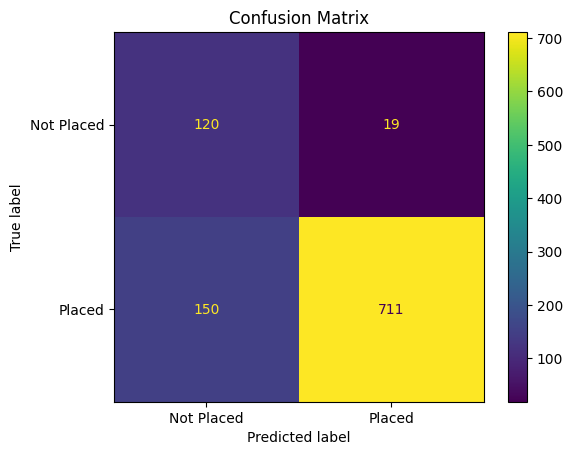

In [142]:
y_pred = best_lr.predict(x_test_cls)

print("\nClassification report:")
print(classification_report(y_placement_test, y_pred))

cm = confusion_matrix(y_placement_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Placed", "Placed"])

disp.plot()
plt.title("Confusion Matrix")
plt.show()

Jika kita bandingkan, hasil evaluation metric terbaik tetap dipegang oleh Logistic Regression dengan class_weight='balanced' sehingga model final untuk classification ini adalah Logistic Regression. Evaluation metric pada test data setelah menggunakan hasil tuning logistic regression adalah:
- Recall kelas 0 = 0.86
- Precision kelas 1 = 0.97
- F1-macro = 0.74

Nilai recall kelas 0 sebesar 0.86 menunjukkan bahwa sekitar 86% mahasiswa yang tidak berhasil ditempatkan (Not Placed) dapat diidentifikasi dengan benar oleh model, sehingga kemampuan model dalam mengenali kelompok ini tergolong baik. Nilai precision kelas 1 sebesar 0.97 mengindikasikan bahwa sekitar 97% mahasiswa yang diprediksi berhasil ditempatkan (Placed) benar-benar termasuk dalam kategori tersebut, sehingga kesalahan prediksi positif sangat kecil dan hasil prediksi dapat dipercaya. Sementara itu, nilai F1-macro sebesar 0.74 menunjukkan bahwa secara rata-rata keseimbangan antara precision dan recall pada kedua kelompok mahasiswa berada di kisaran 74%, yang menandakan bahwa model sudah cukup baik dalam mengklasifikasikan mahasiswa ke dalam dua kategori.

### Check Apakah Korelasi Tinggi Mempengaruhi

In [143]:
features_to_drop = [
    'tenth_percentage',
    'twelfth_percentage',
    'hackathons_participated',
    'attendance_percentage'
]

print(f"Fitur yang di-drop: {features_to_drop}")
print(f"Jumlah fitur baseline: {x_train_cls.shape[1]}")
print(f"Jumlah fitur setelah drop: {x_train_cls.shape[1] - len(features_to_drop)}")
print()

Fitur yang di-drop: ['tenth_percentage', 'twelfth_percentage', 'hackathons_participated', 'attendance_percentage']
Jumlah fitur baseline: 22
Jumlah fitur setelah drop: 18



In [144]:
x_train_cls_dropped = x_train_cls.drop(columns=features_to_drop)

num_cols_dropped = [c for c in x_train_cls_dropped.columns 
                    if x_train_cls_dropped[c].dtype != 'object']
ordinal_col_dropped = [c for c in ordinal_col if c in x_train_cls_dropped.columns]
ohe_col_dropped = [c for c in ohe_col if c in x_train_cls_dropped.columns]

numeric_preprocess_d = Pipeline([
    ('num_imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

ohe_preprocess_d = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('cat_onehot_encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_preprocess_d = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('cat_ordinal_encoder', OrdinalEncoder(categories=ordinal_categories))
])

preprocess_dropped = ColumnTransformer([
    ('num', numeric_preprocess_d, num_cols_dropped),
    ('ohe', ohe_preprocess_d, ohe_col_dropped),
    ('ordinal', ordinal_preprocess_d, ordinal_col_dropped)
], remainder='drop')

lr_tuned_dropped = Pipeline([
    ('preprocessing', preprocess_dropped),
    ('classifier', LogisticRegression(
        random_state=42,
        class_weight='balanced',
        C=0.01,
        penalty='l1',
        solver='liblinear'
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'recall_0': make_scorer(recall_score, pos_label=0),
    'precision_1': make_scorer(precision_score, pos_label=1),
    'f1_macro': 'f1_macro'
}

cv_dropped = cross_validate(
    lr_tuned_dropped, x_train_cls_dropped, y_placement_train,
    cv=skf, scoring=scoring, n_jobs=-1
)

lr_tuned_baseline = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', LogisticRegression(
        random_state=42,
        class_weight='balanced',
        C=0.01,
        penalty='l1',
        solver='liblinear'
    ))
])

cv_baseline = cross_validate(
    lr_tuned_baseline, x_train_cls, y_placement_train,
    cv=skf, scoring=scoring, n_jobs=-1
)

comparison_cls = pd.DataFrame({
    'Metric': ['Recall-0', 'Precision-1', 'F1 Macro'],
    'Baseline (All Features)': [
        cv_baseline['test_recall_0'].mean(),
        cv_baseline['test_precision_1'].mean(),
        cv_baseline['test_f1_macro'].mean()
    ],
    'Dropped Features': [
        cv_dropped['test_recall_0'].mean(),
        cv_dropped['test_precision_1'].mean(),
        cv_dropped['test_f1_macro'].mean()
    ]
})
comparison_cls['Difference'] = comparison_cls['Dropped Features'] - comparison_cls['Baseline (All Features)']

print("Classifier Comparison:")
print(comparison_cls.round(4).to_string(index=False))
print()

Classifier Comparison:
     Metric  Baseline (All Features)  Dropped Features  Difference
   Recall-0                   0.8836            0.8853      0.0018
Precision-1                   0.9761            0.9764      0.0004
   F1 Macro                   0.7001            0.7003      0.0002



Dari sini terlihat bahwa ternyata ketika kita drop kolom yang berkolerasi tinggi, tidak mempengaruhi evaluation metric secara signifikan sehingga untuk klasifikasi saya akan tetap menggunakan semua fitur

### Regression

#### a) Linear Regression

In [145]:
lr_pred_rgs = Pipeline([
    ('preprocessing', preprocess),
    ('regressor', LinearRegression())
])

#### b) Random Forest Regressor

In [146]:
rf_pred_rgs = Pipeline([
    ('preprocessing', preprocess),
    ('regressor', RandomForestRegressor(random_state=42))
])

#### c) XGBoost Regressor

In [147]:
xgb_pred_rgs = Pipeline([
    ('preprocessing', preprocess),
    ('regressor', XGBRegressor(random_state=42))
])

#### d) GradientBoost Regressor

In [148]:
gb_pred_rgs = Pipeline([
    ('preprocessing', preprocess),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

#### e) LightGBM Regressor

In [149]:
lbm_pred_rgs = Pipeline([
    ('preprocessing', preprocess),
    ('regressor', LGBMRegressor(random_state=42))
])

#### f) CatBoost Regressor

In [150]:
cb_pred_rgs = Pipeline([
    ('preprocessing', preprocess),
    ('regressor', CatBoostRegressor(random_state=42))
])

Untuk regresi saya memilih evaluation metric **R^2**, **MAE**, **RMSE**, dan **MAPE**

Dalam memprediksi estimasi gaji mahasiswa, penggunaan **R^2** berfungsi untuk mengukur seberapa besar faktor-faktor seperti CGPA, keterampilan, dan pengalaman magang mampu menjelaskan variasi nominal gaji yang akan diterima. Nilai ini memberikan gambaran apakah fitur yang digunakan memiliki pengaruh signifikan terhadap pendapatan.

Karena hasil prediksi berkaitan langsung dengan ekspektasi finansial, **MAE** menjadi metrik penting untuk menunjukkan rata-rata kesalahan prediksi dalam satuan yang nyata sehingga lebih mudah dipahami. Sebagai contoh, MAE sebesar 500 ribu rupiah berarti bahwa prediksi gaji rata-rata meleset sebesar nominal tersebut dari nilai sebenarnya.

Selain itu, **RMSE** digunakan untuk memberikan penalti lebih besar terhadap kesalahan yang ekstrem. Hal ini penting untuk memastikan bahwa model tidak menghasilkan prediksi yang terlalu jauh dari realita pada individu tertentu, sehingga mengurangi risiko kesalahan besar (outlier).

Terakhir, **MAPE** melengkapi evaluasi dengan menyajikan kesalahan dalam bentuk persentase. Metrik ini krusial karena nilai error yang sama dapat memiliki dampak yang berbeda pada tingkat gaji yang berbeda. Misalnya, selisih 1 juta rupiah akan jauh lebih signifikan bagi lulusan dengan gaji 5 juta dibandingkan dengan yang bergaji 15 juta. Dengan MAPE, konsistensi akurasi model dapat dievaluasi secara proporsional di seluruh rentang gaji.

In [151]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_reg = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
    'neg_mape': 'neg_mean_absolute_percentage_error'
}

models_reg = {
    'Linear Regression': lr_pred_rgs,
    'Random Forest': rf_pred_rgs,
    'XGBoost': xgb_pred_rgs,
    'Gradient Boosting': gb_pred_rgs,
    'LightGBM': lbm_pred_rgs,
    'CatBoost': cb_pred_rgs
}

cv_results_reg = {}
for name, model in models_reg.items():
    cv_results_reg[name] = cross_validate(
        model, x_train_reg, y_salary_train,
        cv=kf, scoring=scoring_reg, n_jobs=-1
    )

summary_data = []
for name, r in cv_results_reg.items():
    rmse_vals = -r['test_neg_rmse']
    mae_vals = -r['test_neg_mae']
    mape_vals = -r['test_neg_mape']
    
    summary_data.append({
        'Model': name,
        'R^2': r['test_r2'].mean(),
        'RMSE': rmse_vals.mean(),
        'MAE': mae_vals.mean(),
        'MAPE': mape_vals.mean()
    })

In [152]:
summary_reg = pd.DataFrame(summary_data).sort_values('R^2', ascending=False).reset_index(drop=True)

print("Cross-Validation Results (Regression Models)")
summary_reg.round(4)

Cross-Validation Results (Regression Models)


,Model,R^2,RMSE,MAE,MAPE
0,Linear Regression,0.7852,1.3913,1.1105,0.0743
1,Gradient Boosting,0.7796,1.4093,1.1086,0.0749
2,CatBoost,0.7746,1.4252,1.1186,0.0756
3,LightGBM,0.7672,1.4480,1.1333,0.0768
4,Random Forest,0.7402,1.5305,1.2085,0.0821
5,XGBoost,0.7248,1.5746,1.2334,0.0834


Jika kita lihat dari tabel di atas, Linear Regression memiliki evaluation metric terbaik, yaitu R^2 sebesar 0.7852, RMSE sebesar 1.3913, MAE 1.1105, dan MAPE 0.0643. Nilai R^2 sebesar 0.7852 menunjukkan bahwa sekitar 78.52% variasi pada nilai target dapat dijelaskan oleh model Linear Regression, sehingga model memiliki kemampuan yang cukup baik dalam menangkap pola data. Nilai RMSE sebesar 1.3913 berarti bahwa rata-rata kesalahan prediksi model adalah sekitar 1.39 satuan dari nilai aktual dengan memberikan penalti lebih besar terhadap error yang ekstrim. Sementara itu, nilai MAE sebesar 1.1105 menunjukkan bahwa secara rata-rata, prediksi model meleset sekitar 1.11 satuan dari nilai sebenarnya. 

Selain itu, nilai MAPE sebesar 0.0743 menunjukkan bahwa rata-rata kesalahan prediksi berada di kisaran 7.43% dari nilai aktual, yang menandakan bahwa model memiliki akurasi yang cukup konsisten secara proporsional di berbagai rentang nilai target. Jika dibandingkan dengan model lain seperti Gradient Boosting, CatBoost, maupun LightGBM, Linear Regression tetap unggul dengan kombinasi nilai R^2 yang paling tinggi serta error (RMSE, MAE, dan MAPE) yang relatif rendah. Secara keseluruhan, hal ini menunjukkan bahwa Linear Regression merupakan model yang paling optimal untuk digunakan pada kasus prediksi ini karena mampu memberikan keseimbangan terbaik antara kemampuan menjelaskan variansi data dan tingkat kesalahan prediksi yang rendah.

## Cek Ketika Drop Kolom Korelasi Tinggi

In [153]:
x_train_reg_dropped = x_train_reg.drop(columns=features_to_drop)

num_cols_reg_dropped = [c for c in x_train_reg_dropped.columns 
                         if x_train_reg_dropped[c].dtype != 'object']
ordinal_col_reg_dropped = [c for c in ordinal_col if c in x_train_reg_dropped.columns]
ohe_col_reg_dropped = [c for c in ohe_col if c in x_train_reg_dropped.columns]

preprocess_reg_dropped = ColumnTransformer([
    ('num', numeric_preprocess_d, num_cols_reg_dropped),
    ('ohe', ohe_preprocess_d, ohe_col_reg_dropped),
    ('ordinal', ordinal_preprocess_d, ordinal_col_reg_dropped)
], remainder='drop')

lr_reg_dropped = Pipeline([
    ('preprocessing', preprocess_reg_dropped),
    ('regressor', LinearRegression())
])

lr_reg_baseline = Pipeline([
    ('preprocessing', preprocess),
    ('regressor', LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring_reg = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
    'neg_mape': 'neg_mean_absolute_percentage_error'
}

cv_reg_dropped = cross_validate(
    lr_reg_dropped, x_train_reg_dropped, y_salary_train,
    cv=kf, scoring=scoring_reg, n_jobs=-1
)

cv_reg_baseline = cross_validate(
    lr_reg_baseline, x_train_reg, y_salary_train,
    cv=kf, scoring=scoring_reg, n_jobs=-1
)

comparison_reg = pd.DataFrame({
    'Metric': ['R^2', 'RMSE', 'MAE', 'MAPE (%)'],
    'Baseline (All Features)': [
        cv_reg_baseline['test_r2'].mean(),
        -cv_reg_baseline['test_neg_rmse'].mean(),
        -cv_reg_baseline['test_neg_mae'].mean(),
        -cv_reg_baseline['test_neg_mape'].mean() * 100
    ],
    'Dropped Features': [
        cv_reg_dropped['test_r2'].mean(),
        -cv_reg_dropped['test_neg_rmse'].mean(),
        -cv_reg_dropped['test_neg_mae'].mean(),
        -cv_reg_dropped['test_neg_mape'].mean() * 100
    ]
})
comparison_reg['Difference'] = comparison_reg['Dropped Features'] - comparison_reg['Baseline (All Features)']

print("Regressor Comparison:")
print(comparison_reg.round(4).to_string(index=False))

Regressor Comparison:
  Metric  Baseline (All Features)  Dropped Features  Difference
     R^2                   0.7852            0.7634     -0.0218
    RMSE                   1.3913            1.4600      0.0687
     MAE                   1.1105            1.1628      0.0523
MAPE (%)                   7.4315            7.8189      0.3874


Ternyata pada regresi, drop fitur malah membuat keempat evaluation metric memburuk, dimana model jadi kurang menjelaskan variance dari data sebenarnya. Error (RMSE, MAE, dan MAPE) juga meningkat. Oleh karena itu saya memilih untuk tidak drop fitur yang berkolerasi tinggi

Pada projek ini, model final saya untuk classification adalah Logistic Regression dan untuk regression adalah Linear Regression. 